In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# KNeighborsRegressor: 선택된 K개 이웃의 타깃(Target) 값들을 평균 내어 최종 예측값으로 사용
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings(action='ignore')

In [2]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name='boston', version=1, as_frame=True)

In [3]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [5]:
X = boston.data
y = boston.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

In [8]:
k = 3
knn_regressor = KNeighborsRegressor(n_neighbors=k)
knn_regressor.fit(X_train, y_train)
y_pred = knn_regressor.predict(X_test)


In [9]:
print("mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("R^2 score: %.2f" % r2_score(y_test, y_pred))

mean squared error: 21.66
R^2 score: 0.70


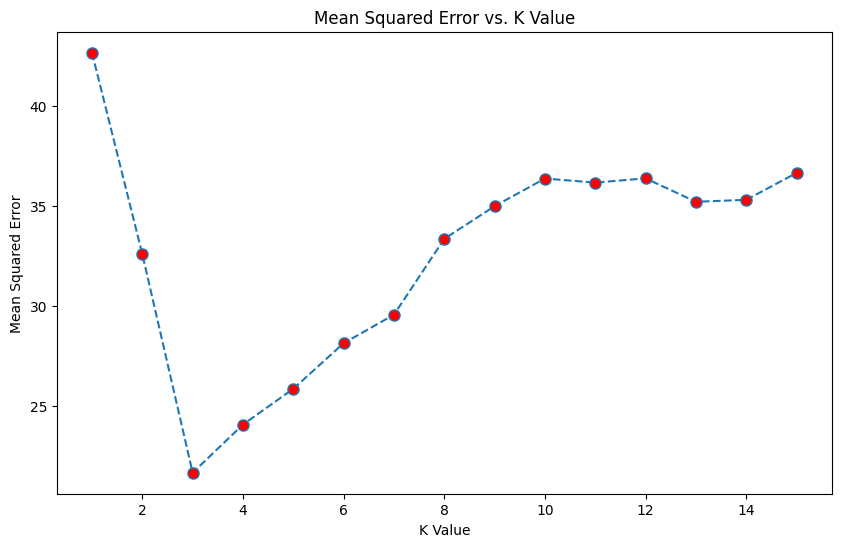

In [10]:
mse_values = []

for i in range(1, 16):
    knn_i = KNeighborsRegressor(n_neighbors=i)
    knn_i.fit(X_train, y_train)
    y_pred_i = knn_i.predict(X_test)
    mse_values.append(mean_squared_error(y_test, y_pred_i))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), mse_values, marker='o', linestyle='dashed', markersize=8, markerfacecolor='red')
plt.title("Mean Squared Error vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error")
plt.show()